# Ablation — Window Size

**Models:** Logistic Regression, Convolutional Autoencoder  
**Variable:** Window size ∈ {64, 128, 256} frames (~0.64 s, ~1.28 s, ~2.56 s)  
**Split:** Session 1 => train, Session 2 => test

---

### Question

All previous experiments used `WINDOW_SIZE=32` (~0.32 s). This was an arbitrary default.
Longer windows integrate more signal potentially capturing slower physiological patterns
like breathing (~4 s) or postural sway (~10 s) but also yield fewer training samples.

**Is window size a meaningful hyperparameter given our current data, or is session drift
the dominant bottleneck regardless?**

We test LR (supervised) and AE (anomaly detection) at three larger window sizes
with 50 % step overlap.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import os

SAVE_DIR  = 'feasibility-study-outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

DATA_DIR     = "../data/feasibility-study/processed"
WINDOW_SIZES = [64, 128, 256]
EPOCHS_AE    = 60
BATCH_SIZE   = 256
LR           = 1e-3

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

Device: mps


In [6]:
def make_windows(X, y, ws, step): # shared utility see preprocessing in nb 00
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - ws + 1, step):
            Xw.append(Xl[start:start + ws])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)


class CSIAutoencoder(nn.Module):
    def __init__(self, n_features=55):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,         64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 128, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv1d(128, n_features, kernel_size=3, padding=1),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


def run_lr(ws):
    step = ws // 2
    Xtr, ytr = make_windows(X_train_raw, y_train_raw, ws, step)
    Xte, yte = make_windows(X_test_raw,  y_test_raw,  ws, step)
    clf = LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000, random_state=42)
    clf.fit(Xtr.reshape(len(Xtr), -1), ytr)
    prob = clf.predict_proba(Xte.reshape(len(Xte), -1))[:, 1]
    return roc_auc_score(yte, prob)


def run_ae(ws):
    step     = ws // 2
    Xtr, ytr = make_windows(X_train_raw, y_train_raw, ws, step)
    Xte, yte = make_windows(X_test_raw,  y_test_raw,  ws, step)

    empty_idx = np.where(ytr == 0)[0]
    X_empty   = Xtr[empty_idx]
    n_val     = int(len(X_empty) * 0.2)
    X_ae_val  = X_empty[-n_val:]
    X_ae_tr   = X_empty[:-n_val]

    model     = CSIAutoencoder().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    tr_dl     = DataLoader(TensorDataset(torch.from_numpy(X_ae_tr)), batch_size=BATCH_SIZE, shuffle=True)

    for _ in range(EPOCHS_AE):
        model.train()
        for (Xb,) in tr_dl:
            Xb = Xb.permute(0, 2, 1).to(DEVICE)
            optimizer.zero_grad()
            criterion(model(Xb), Xb).backward()
            optimizer.step()

    def errors(X_np):
        model.eval()
        dl = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=512)
        out = []
        with torch.no_grad():
            for (Xb,) in dl:
                Xb = Xb.permute(0, 2, 1).to(DEVICE)
                out.append(((model(Xb) - Xb)**2).mean(dim=(1,2)).cpu().numpy())
        return np.concatenate(out)

    return roc_auc_score(yte, errors(Xte))

In [7]:
results_lr, results_ae = [], []

for ws in WINDOW_SIZES:
    auc_lr = run_lr(ws)
    auc_ae = run_ae(ws)
    results_lr.append(auc_lr)
    results_ae.append(auc_ae)
    print(f"WS={ws:4d}  LR AUC={auc_lr:.4f}  AE AUC={auc_ae:.4f}")

WS=  64  LR AUC=0.6264  AE AUC=0.7485
WS= 128  LR AUC=0.6603  AE AUC=0.7426
WS= 256  LR AUC=0.6427  AE AUC=0.7387


We add the WS=32 baseline from notebooks 01 and 04 to make the comparison table complete.

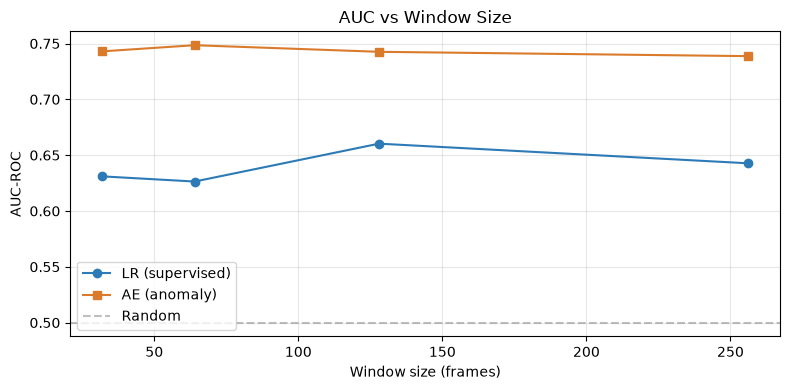


Summary:
  WS=  32  LR=0.631  AE=0.743
  WS=  64  LR=0.626  AE=0.748
  WS= 128  LR=0.660  AE=0.743
  WS= 256  LR=0.643  AE=0.739


In [8]:
# Add baseline WS=32 for comparison
ws_all    = [32] + WINDOW_SIZES
lr_all    = [0.631] + results_lr   # from notebook 01
ae_all    = [0.743] + results_ae   # from notebook 04

plt.figure(figsize=(8, 4))
plt.plot(ws_all, lr_all, "o-", label="LR (supervised)", color='#2C7BB6')
plt.plot(ws_all, ae_all, "s-", label="AE (anomaly)",    color='#D97B2B')
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
plt.xlabel("Window size (frames)")
plt.ylabel("AUC-ROC")
plt.title("AUC vs Window Size")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_auc_vs_window_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary:")
for ws, lr, ae in zip(ws_all, lr_all, ae_all):
    print(f"  WS={ws:4d}  LR={lr:.3f}  AE={ae:.3f}")

## Results Analysis

| Window size | Duration | LR AUC | AE AUC |
|---|---|---|---|
| 32 (baseline) | ~0.32 s | ~0.631 | ~0.743 |
| 64 | ~0.64 s | ~0.626 | ~0.748 |
| 128 | ~1.28 s | ~0.660 | ~0.742 |
| 256 | ~2.56 s | ~0.643 | ~0.740 |

**AE AUC is flat across all window sizes (0.740–0.748).** LR shows a slight peak at
WS=128 but the variation is within noise. Neither model benefits consistently from
longer windows in the 32–256 range.

**Conclusion: window size is not the bottleneck.** The performance ceiling is set by
cross-session distribution shift, not by the temporal context available within a window.
At WS=256 (~2.56 s) we still cannot capture a full breathing cycle (~4 s), and even
if we could, the absolute amplitudes change between sessions in a way that makes any
within-window pattern unreliable.

This motivates the next experiment: push to dramatically longer windows (15 s, 30 s)
that can capture full physiological cycles, accepting the data-scarcity trade-off.
See notebook 08.